# 4.1 — Summary Statistics & Distributions


**Goal:** Compute descriptive statistics for all key numerical variables, and visualize price, review score, listing count per host, and availability distributions.

---
### Notebook Structure
1. Setup & Data Loading
2. Descriptive Statistics Overview
3. Price Distributions (by neighbourhood, room type, property type)
4. Listings per Host — Power Law Dynamics
5. Review Score Distributions — Rating Inflation Check
6. Availability Patterns

---
## 1. Setup & Data Loading

We load the Gold layer `listing_master.parquet` which already has cleaned prices, capped outliers, and all engineered columns. The raw `listings.csv` is also referenced for columns dropped in the pipeline.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
ACCENT   = '#E84393'
NEUTRAL  = '#4A4A4A'
FIG_W    = 14


GOLD_PATH = '../../data/gold/listing_master.parquet'

df = pd.read_parquet(GOLD_PATH)
print(f'Shape: {df.shape}')
df.dtypes

Shape: (22476, 99)


id                                   int64
listing_url                         object
scrape_id                            int64
last_scraped                        object
source                              object
                                    ...   
is_revenue_estimate_approximate       bool
occupancy_includes_host_blocks        bool
host_tenure_years                  float64
review_frequency_per_year          float64
price_per_bedroom                  float64
Length: 99, dtype: object

---
## 2. Descriptive Statistics Overview

We compute `.describe()` on all core numerical columns and inspect missing-value counts. This gives us the baseline before visualising individual distributions.

In [2]:
NUMERIC_COLS = [
    'price_clean', 'price_capped', 'accommodates', 'bathrooms_clean',
    'bedrooms', 'minimum_nights', 'availability_365',
    'number_of_reviews', 'review_scores_rating',
    'calculated_host_listings_count',
    'estimated_annual_revenue_approx', 'occupancy_rate_upper_bound'
]

# Keep only columns that exist in the Gold layer
present = [c for c in NUMERIC_COLS if c in df.columns]

desc = df[present].describe().T
desc['missing_%'] = (df[present].isna().sum() / len(df) * 100).round(2)
desc.style.background_gradient(subset=['mean', 'std'], cmap='Blues').format(precision=2)

,count,mean,std,min,25%,50%,75%,max,missing_%
price_clean,22476.00,3281.00,9048.34,161.00,950.00,1526.00,2975.25,714885.00,0.00
price_capped,22476.00,2960.71,4246.95,161.00,950.00,1526.00,2975.25,28323.50,0.00
accommodates,22476.00,3.76,2.41,1.00,2.00,3.00,4.00,16.00,0.00
bedrooms,22453.00,1.84,1.37,0.00,1.00,1.00,2.00,50.00,0.10
minimum_nights,22476.00,3.94,17.76,1.00,1.00,2.00,3.00,999.00,0.00
availability_365,22476.00,231.67,105.76,0.00,152.00,256.00,324.00,365.00,0.00
number_of_reviews,22476.00,27.27,50.93,0.00,1.00,8.00,30.00,843.00,0.00
review_scores_rating,18007.00,4.76,0.43,1.00,4.71,4.89,5.00,5.00,19.88
calculated_host_listings_count,22476.00,13.61,29.63,1.00,1.00,2.00,9.00,175.00,0.00
estimated_annual_revenue_approx,22476.00,405878.27,807863.56,0.00,56647.00,168688.00,398894.00,10338077.50,0.00


> **Business Interpretation: Baseline Descriptive Statistics**
> A macro-level review of the descriptive statistics reveals several structural realities of the Cape Town Airbnb market:
> 
> * **Pricing Skew & Outlier Management:** The raw mean price (`price_clean`) is heavily skewed by ultra-luxury properties (Max: R714,885). Applying the 99th percentile cap (`price_capped`) successfully stabilized the mean (R2,960) and standard deviation, bringing the statistical average much closer to the true market median (R1,526).

> * **Typical Inventory:** The median listing accommodates 3 guests and has 1 bedroom, with a median minimum stay of 2 nights. This indicates the Cape Town market is overwhelmingly optimized for short-term tourist stays for couples and small groups, rather than large families or corporate mid-term rentals.

> * **Revenue & Engagement Inequity:** The median estimated annual revenue is ~R168,000, while the mean is ~R405,000. Similarly, the median review count is just 8, while the maximum is 843. This confirms a highly "winner-takes-all" dynamic: a small cohort of highly successful, frequently booked listings generates the vast majority of platform revenue, while the "average" host earns a modest supplemental income. 

> * **Rating Inflation:** The median review score is 4.89 out of 5.00. This confirms severe rating inflation platform-wide, meaning raw scores alone are poor differentiators of quality for the ranking algorithm.

---
## 3. Price Distributions

> **Caveat (from data dictionary):** `price_clean` uses the listing price from `listings.csv` denominated in ZAR (the `$` symbol is a formatting artifact from Inside Airbnb). Calendar prices are 100% null and cannot be used. Listings above the 99th percentile are marked `is_price_outlier = True` and excluded from distribution plots but retained in the raw data.

### 3a. Overall Nightly Price Distribution (Capped)

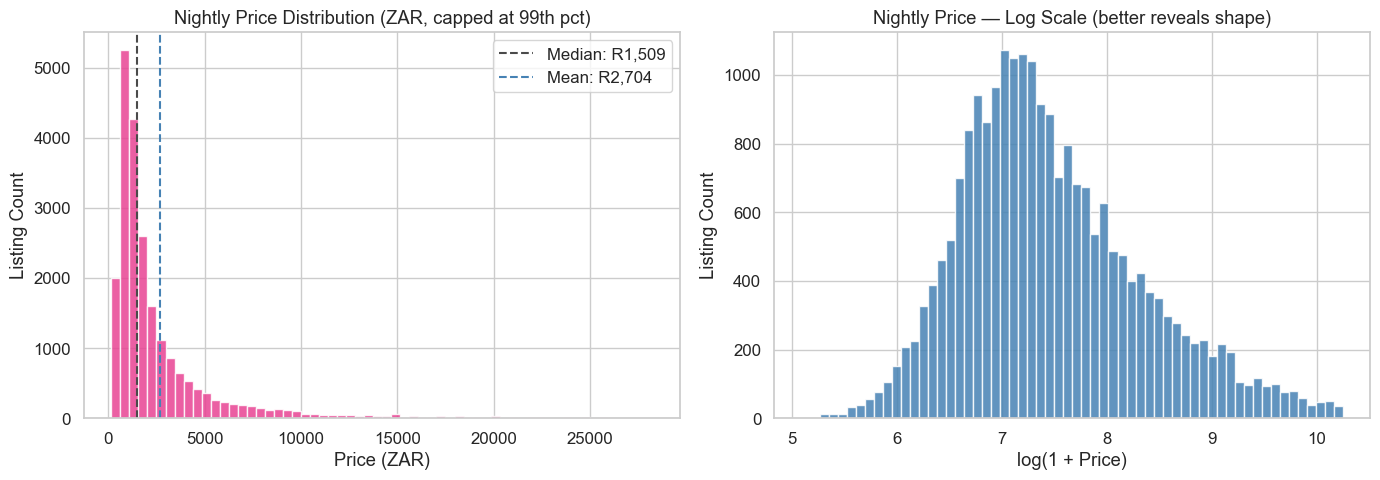

Median nightly price : R1,509
Mean nightly price   : R2,704
Listings excluded (outliers): 225 (1.0%)


In [3]:
non_outlier = df[df['is_price_outlier'] == False]['price_capped'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Histogram
axes[0].hist(non_outlier, bins=60, color=ACCENT, edgecolor='white', alpha=0.85)
axes[0].axvline(non_outlier.median(), color=NEUTRAL, ls='--', lw=1.5, label=f'Median: R{non_outlier.median():,.0f}')
axes[0].axvline(non_outlier.mean(),   color='steelblue', ls='--', lw=1.5, label=f'Mean: R{non_outlier.mean():,.0f}')
axes[0].set_title('Nightly Price Distribution (ZAR, capped at 99th pct)')
axes[0].set_xlabel('Price (ZAR)')
axes[0].set_ylabel('Listing Count')
axes[0].legend()

# Log-scale version — reveals the true shape since price is right-skewed
axes[1].hist(np.log1p(non_outlier), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Nightly Price — Log Scale (better reveals shape)')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Listing Count')

plt.tight_layout()
plt.savefig('../../reports/figures/4_1_price_overall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median nightly price : R{non_outlier.median():,.0f}")
print(f"Mean nightly price   : R{non_outlier.mean():,.0f}")
print(f"Listings excluded (outliers): {df['is_price_outlier'].sum()} "
      f"({df['is_price_outlier'].mean()*100:.1f}%)")

> **Business Interpretation: Pricing Dynamics & Market Segmentation**
> 
> * **The Right-Skewed Market Reality:** The standard histogram (left) reveals a severe right-skew. The vast majority of the Cape Town market is clustered at the lower end of the pricing spectrum, with a median nightly price of **R1,509**. However, the mean is pulled much higher (**R2,704**) by a long "tail" of expensive properties, even after capping the extreme top 1% of outliers. 
> * **The "True" Shape of Demand (Log Scale):** Because standard histograms obscure the shape of skewed data, the log-transformed chart (right) is critical. It reveals a approximately log-normal distribution with mild residual skew when prices are viewed on a logarithmic scale. 
> 

> **Strategic Takeaways:**
> 1. **For Pricing Algorithms (Data Science):** Standard linear regression models will fail to predict prices accurately in this market because the data violates the assumption of normality. Any machine learning model built to predict or recommend nightly prices must train on the *log-transformed* price to maintain accuracy across both budget and luxury tiers.
> 2. **For Platform Operators (Business Strategy):** Cape Town is fundamentally a mid-market destination, but the significant volume of supply stretching into the R5,000–R15,000 range indicates a robust luxury sub-market. Marketing efforts and search filters should be designed to clearly bifurcate these two segments (e.g., standard "Airbnb" vs. "Airbnb Luxe"), as the guest expectations and host behaviors in the long tail will differ drastically from the core median cluster.

### 3b. Price by Room Type

Entire homes are expected to command a significant premium over private/shared rooms. The box plot reveals median and spread simultaneously.

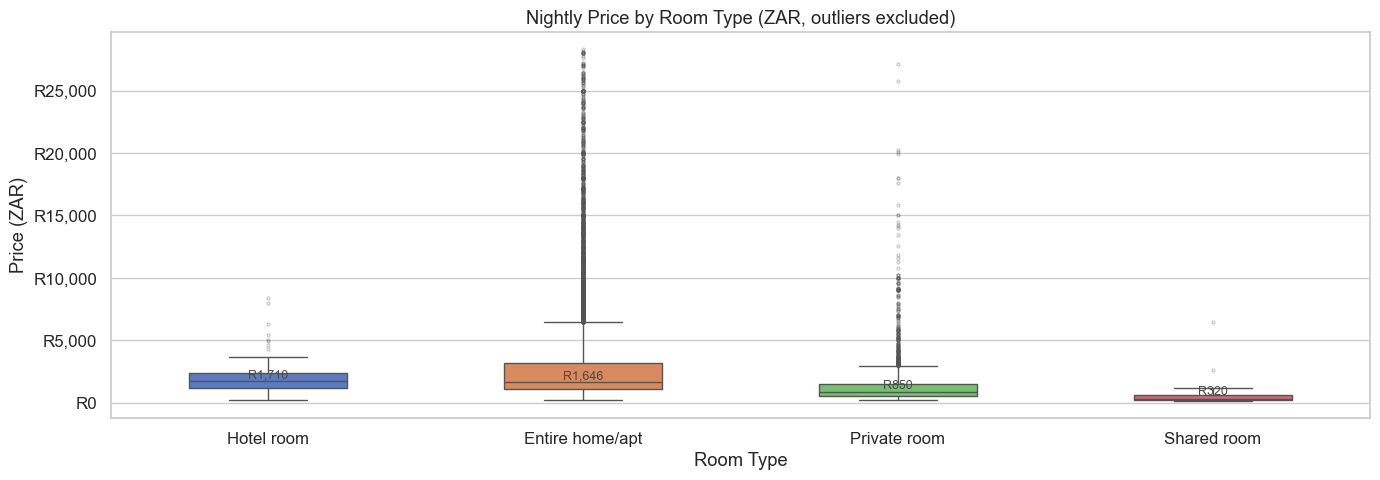

In [4]:
plot_df = df[df['is_price_outlier'] == False].copy()

room_order = (
    plot_df.groupby('room_type')['price_capped']
    .median().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(FIG_W, 5))
sns.boxplot(
    data=plot_df, x='room_type', y='price_capped',
    order=room_order, palette='muted', width=0.5,
    flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=ax
)
ax.set_title('Nightly Price by Room Type (ZAR, outliers excluded)')
ax.set_xlabel('Room Type')
ax.set_ylabel('Price (ZAR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R{x:,.0f}'))

# Annotate medians
for i, rt in enumerate(room_order):
    med = plot_df[plot_df['room_type'] == rt]['price_capped'].median()
    ax.text(i, med + 50, f'R{med:,.0f}', ha='center', va='bottom', fontsize=9, color=NEUTRAL)

plt.tight_layout()
plt.savefig('../../reports/figures/4_1_price_by_room_type.png', dpi=150, bbox_inches='tight')
plt.show()

> **Business Interpretation: Asset Class & Pricing Elasticity**
> 
> * **The Hotel vs. Home Dynamic:** Surprisingly, the median price for a "Hotel room" (R1,710) is slightly higher than an "Entire home/apt" (R1,646). However, the *variance* tells the real story. Hotel pricing is tightly clustered—indicating a highly commoditized, predictable market. In contrast, "Entire homes" have a massive interquartile range and a towering tail of high-priced outliers (stretching to R25,000+). 
> * **The Budget Segmentation:** "Private rooms" (R850) operate at exactly half the median price of entire homes, capturing the budget-conscious traveler, while "Shared rooms" (R320) represent a highly localized, distinct backpacker tier.
> 
> **Strategic Takeaways:**
> 1. **For Real Estate Investors:** "Entire homes" offer massive pricing elasticity. An investor can drastically increase their nightly rate by adding luxury amenities (pools, views), pushing their property into that highly profitable upper tail. Hotel rooms, however, hit a pricing ceiling very quickly.
> 2. **For Platform UI/UX:** The intent of a guest booking a R1,700 Hotel Room (seeking daily cleaning, room service, predictability) is entirely different from a guest booking a R1,700 Entire Home (seeking a kitchen, privacy, space). The platform must ensure its search filters and property tags clearly distinguish these asset classes, rather than just grouping them by similar price points, to prevent guest dissatisfaction.

### 3c. Price by Neighbourhood (Top 20 by listing count)

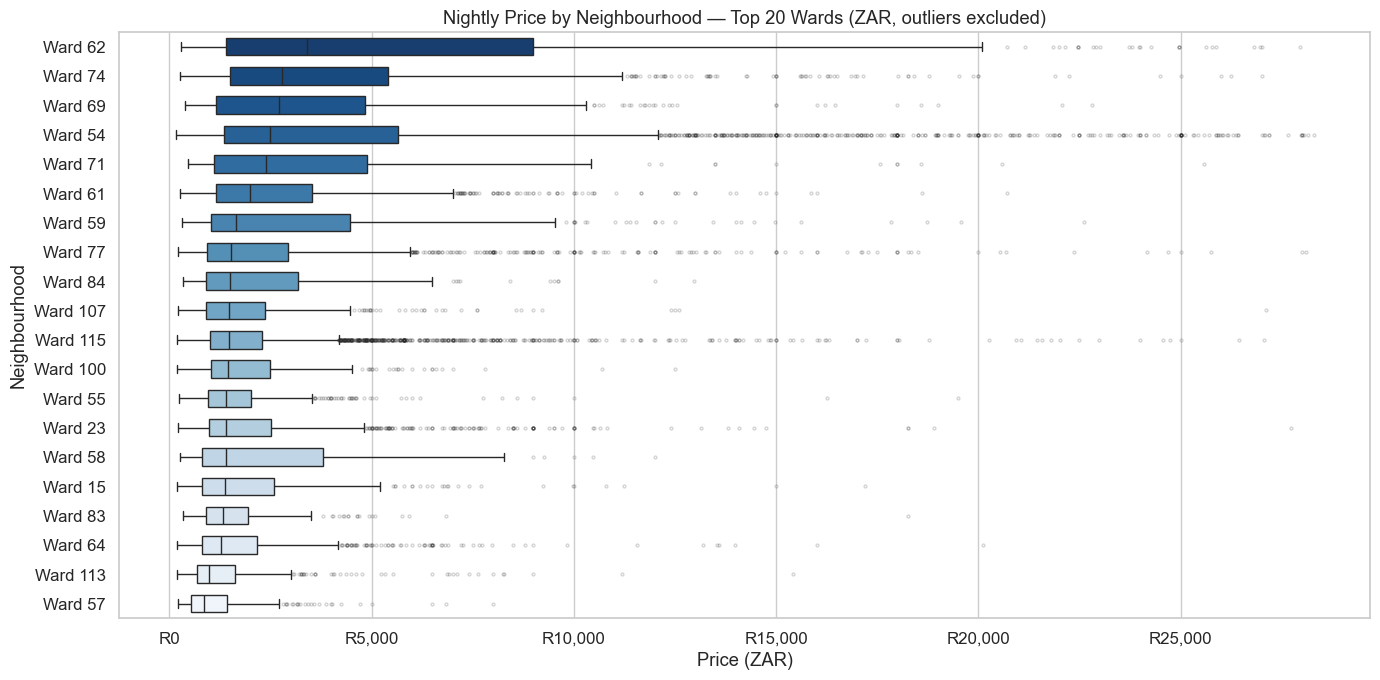

In [5]:
top_hoods = (
    df['neighbourhood_cleansed'].value_counts().head(20).index.tolist()
)
hood_df = plot_df[plot_df['neighbourhood_cleansed'].isin(top_hoods)].copy()

hood_order = (
    hood_df.groupby('neighbourhood_cleansed')['price_capped']
    .median().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(FIG_W, 7))
sns.boxplot(
    data=hood_df, y='neighbourhood_cleansed', x='price_capped',
    order=hood_order, palette='Blues_r', width=0.6,
    flierprops=dict(marker='o', markersize=2, alpha=0.2), ax=ax
)
ax.set_title('Nightly Price by Neighbourhood — Top 20 Wards (ZAR, outliers excluded)')
ax.set_ylabel('Neighbourhood')
ax.set_xlabel('Price (ZAR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R{x:,.0f}'))
plt.tight_layout()
plt.savefig('../../reports/figures/4_1_price_by_neighbourhood.png', dpi=150, bbox_inches='tight')
plt.show()

3d. Price by Property Type (Grouped)

> **Business Interpretation: Geographic Pricing Tiers & Market Stratification**
> 
> * **Clear Market Stratification:** The top 20 high-volume wards in Cape Town are distinctly stratified into premium and budget tiers. Ward 62 operates in an entirely different economic reality than Ward 57. The median price in Ward 62 is higher than the 75th percentile of almost all wards from Ward 107 downwards.
> * **The "Premium" Variance:** The top 5 highest-priced wards (62, 74, 69, 54, 71) not only command higher median prices but also display significantly wider interquartile ranges (the blue boxes) and incredibly long tails of extreme outliers stretching past R20,000. This indicates these are highly heterogeneous luxury markets containing both standard premium homes and ultra-luxury estates.
> * **The "Commoditized" Budget Tier:** Conversely, the bottom 10 wards (from Ward 115 downwards) show tightly constrained pricing. The boxes are narrow, and the outlier tails are much shorter. In these areas, pricing is highly commoditized; hosts have very little pricing power to charge a premium over their neighbors.
> 
> **Strategic Takeaways:**
> 1. **For Revenue Management / Pricing Engines:** A "one size fits all" pricing algorithm will fail here. A model must assign a much higher weight to the `neighbourhood_cleansed` variable, recognizing that a luxury amenity (like a pool) might add R5,000 to the nightly rate in Ward 62, but only R500 in Ward 57.
> 2. **For Host Acquisition / Sales:** If the platform intends to grow overall Gross Booking Value (GBV), host acquisition teams should aggressively target new listings in the top 5 wards, where the baseline nightly rates (and thus platform commission fees) are structurally much higher.

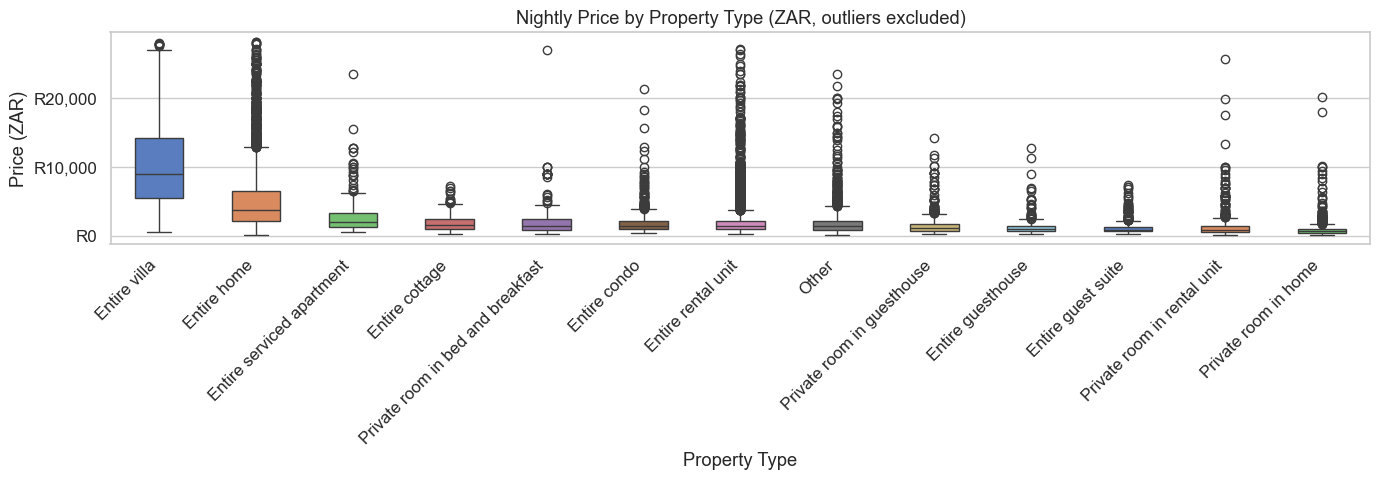

In [6]:
prop_order = (
    plot_df.groupby('property_type_grouped')['price_capped']
    .median().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(FIG_W, 5))
sns.boxplot(
    data=plot_df, x='property_type_grouped', y='price_capped',
    order=prop_order, palette='muted', width=0.5, ax=ax
)
ax.set_title('Nightly Price by Property Type (ZAR, outliers excluded)')
ax.set_xlabel('Property Type')
ax.set_ylabel('Price (ZAR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> **Business Interpretation: Asset Class Stratification & The "Villa" Premium**
> 
> * **The "Villa" Exception:** The "Entire villa" category operates as a completely distinct micro-economy. Its median price (roughly R9,000) is substantially higher than the 75th percentile of almost every other property type. Furthermore, its massive interquartile range (the tall blue box) indicates extreme variance—villas are priced entirely on unique, luxury characteristics rather than a standard market rate.
> * **Homes vs. Condos/Apartments:** "Entire homes" command a noticeable premium over "Entire rental units" or "Condos." However, all three of these categories feature a towering vertical line of outliers stretching up to R20,000+. This indicates that while apartments are cheaper on average, a luxury penthouse condo can easily command the same extreme premium as a luxury standalone home.
> * **The Commoditized Tail:** From "Private room in bed and breakfast" downwards, the boxes become incredibly compressed. Pricing for guest suites and private rooms is highly rigid and commoditized. Hosts in this tier are competing almost exclusively on price, with very little elasticity to charge a premium.
> 
> **Strategic Takeaways:**
> 1. **For Platform UI/UX:** "Entire villas" heavily skew general search results. The platform should consider creating a hard filter or a separate tier (e.g., "Luxe Tier") for villas so budget-conscious users aren't overwhelmed by R10,000+/night listings in standard searches.
> 2. **For Revenue Operations:** The dense clustering of high-priced outliers in "Entire homes" and "Entire condos" represents the highest ROI for the platform. Account management teams should provide dedicated support to hosts in these categories to ensure they do not churn to competing platforms.

---
## 4. Listings per Host — Power Law Dynamics

A classic Airbnb market pattern is that a small fraction of professional/commercial hosts control a disproportionate share of listings. We visualise the distribution and compute the Lorenz-style concentration metric.

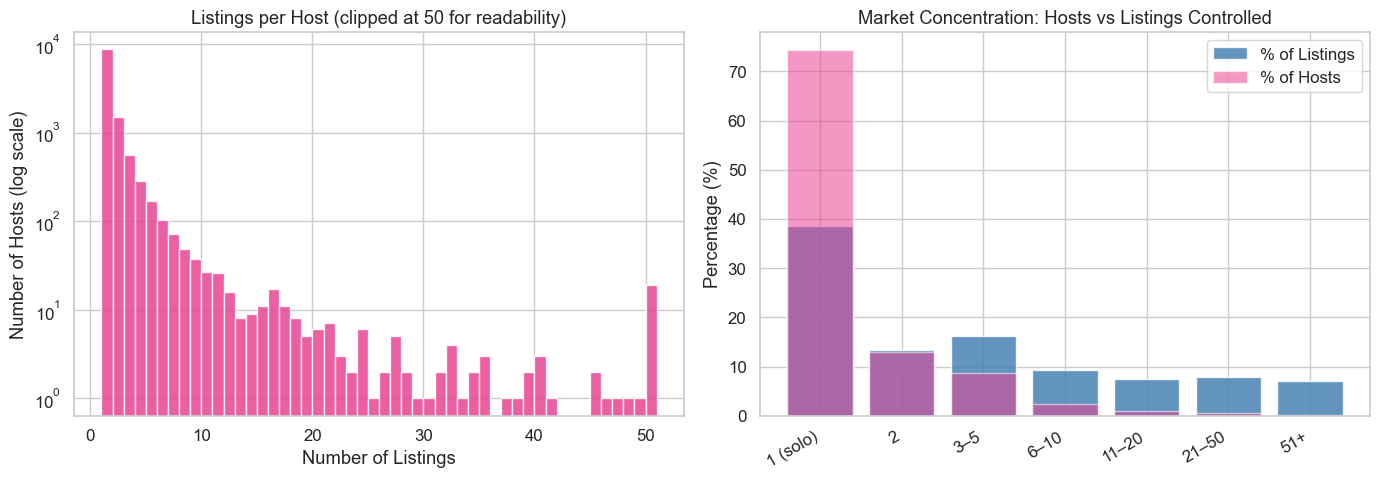

          hosts  total_listings  pct_hosts  pct_listings
segment                                                 
1 (solo)   8674            8674  74.314599     38.592276
2          1514            3028  12.971213     13.472148
3–5        1005            3632   8.610350     16.159459
6–10        287            2110   2.458876      9.387791
11–20       117            1691   1.002399      7.523581
21–50        57            1770   0.488348      7.875067
51+          18            1571   0.154215      6.989678


In [ ]:
host_counts = df.groupby('host_id')['id'].count().rename('listing_count').reset_index()


bins = [0, 1, 2, 5, 10, 20, 50, 500] 
labels = ['1 (solo)', '2', '3–5', '6–10', '11–20', '21–50', '51+']

host_counts['segment'] = pd.cut(
    host_counts['listing_count'], bins=bins, labels=labels, right=True
)

seg_summary = (
    host_counts.groupby('segment', observed=True)
    .agg(hosts=('host_id', 'count'), total_listings=('listing_count', 'sum'))
    .assign(
        pct_hosts=lambda x: x['hosts'] / x['hosts'].sum() * 100,
        pct_listings=lambda x: x['total_listings'] / x['total_listings'].sum() * 100
    )
)

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Distribution histogram
axes[0].hist(
    host_counts['listing_count'].clip(upper=50),
    bins=range(1, 52), color=ACCENT, edgecolor='white', alpha=0.85
)
axes[0].set_title('Listings per Host (clipped at 50 for readability)')
axes[0].set_xlabel('Number of Listings')
axes[0].set_ylabel('Number of Hosts')
axes[0].set_yscale('log')
axes[0].set_ylabel('Number of Hosts (log scale)')

# Host segment — % listings controlled
x = range(len(seg_summary))
axes[1].bar(x, seg_summary['pct_listings'], color='steelblue', alpha=0.85, label='% of Listings')
axes[1].bar(x, seg_summary['pct_hosts'],    color=ACCENT,     alpha=0.55, label='% of Hosts')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].set_title('Market Concentration: Hosts vs Listings Controlled')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../../reports/figures/4_1_host_power_law.png', dpi=150, bbox_inches='tight')
plt.show()

print(seg_summary.to_string())

> **Business Interpretation: Host Power Law & Platform Supply Risk**
> 
> * **The "Solo Host" Baseline:** The data confirms that the vast majority of hosts on the platform are individuals managing a single property. "Solo hosts" account for **74.3%** of all hosts. However, despite their massive numbers, they only control **38.5%** of the total platform inventory.
> * **The "Mega Host" Concentration:** At the opposite end of the spectrum, we see a severe market concentration. If we look at commercial operators managing 11 or more properties (the 11-20, 21-50, and 51+ segments combined), they represent a mere **1.6%** of total hosts (192 hosts in total). Yet, this tiny fraction of "Mega Hosts" controls **22.3%** of the entire market supply (5,032 listings).
> * **The Professional "Middle Class":** Hosts with 3-10 listings make up about 11% of the host base but control roughly 25% of the inventory, representing a growing segment of professional, mid-sized property management companies.
> 
> **Strategic Takeaways:**
> 1. **For Key Account Management:** The platform has a highly vulnerable supply chain. Losing just 18 specific hosts (the 51+ tier) would wipe out 7% of Cape Town's inventory overnight. These commercial hosts must be assigned dedicated account managers and offered enterprise-level API tools to ensure platform loyalty.
> 2. **For Marketing & Guest Experience:** While commercial hosts provide essential supply volume, "Solo hosts" are often the primary driver of the authentic "Airbnb experience" that guests seek. The platform must balance its dual nature: treating the top 2% of hosts as B2B commercial partners, while continuing to market to the 74% as a peer-to-peer side-hustle platform.

---
## 5. Review Score Distributions — Rating Inflation

Airbnb is well-documented to suffer from **rating inflation** — guests tend to give 4.8–5.0 unless they have a serious complaint. We test this by examining the full distribution and checking where the bulk of scores cluster.

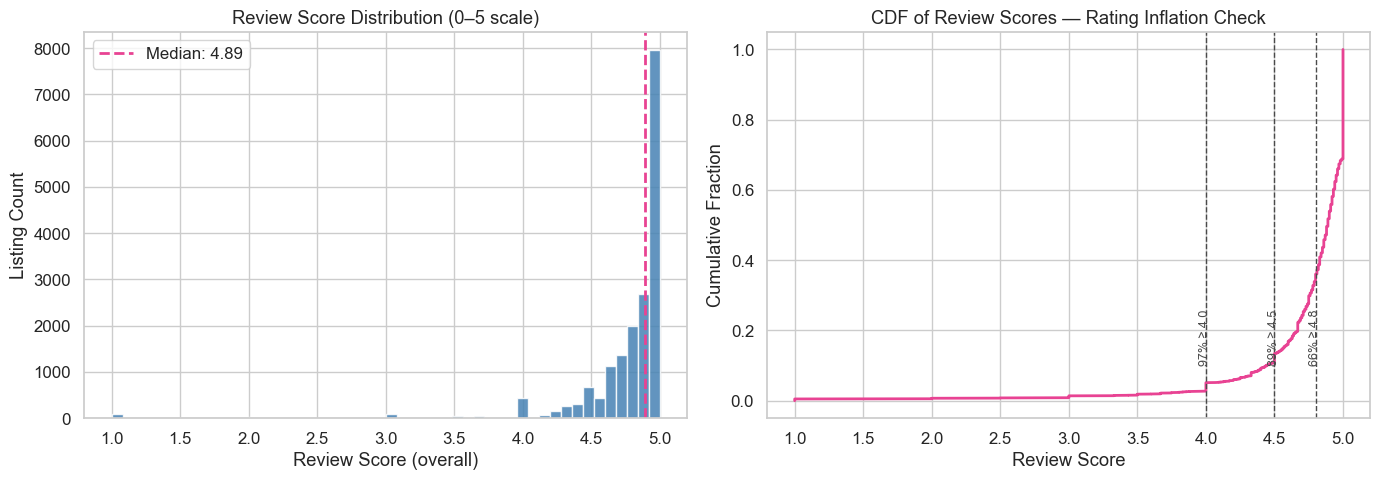

Pct of reviewed listings scoring >= 4.5 : 89.2%
Pct of reviewed listings scoring >= 4.8 : 66.1%
Listings with NO review (null)          : 4469 (19.9%)


In [ ]:
scores = df['review_scores_rating'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Histogram
axes[0].hist(scores, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(scores.median(), color=ACCENT, ls='--', lw=2, label=f'Median: {scores.median():.2f}')
axes[0].set_title('Review Score Distribution (0–5 scale)')
axes[0].set_xlabel('Review Score (overall)')
axes[0].set_ylabel('Listing Count')
axes[0].legend()


sorted_scores = np.sort(scores)
cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1].plot(sorted_scores, cdf, color=ACCENT, lw=2)
for threshold in [4.0, 4.5, 4.8]:
    pct = (scores >= threshold).mean() * 100
    axes[1].axvline(threshold, ls='--', color=NEUTRAL, lw=1)
    axes[1].text(threshold - 0.05, 0.1, f'{pct:.0f}% ≥ {threshold}', rotation=90,
                 va='bottom', fontsize=9, color=NEUTRAL)
axes[1].set_title('CDF of Review Scores — Rating Inflation Check')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Cumulative Fraction')

plt.tight_layout()
plt.savefig('../../reports/figures/4_1_review_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pct of reviewed listings scoring >= 4.5 : {(scores >= 4.5).mean()*100:.1f}%")
print(f"Pct of reviewed listings scoring >= 4.8 : {(scores >= 4.8).mean()*100:.1f}%")
print(f"Listings with NO review (null)          : {df['review_scores_rating'].isna().sum()} "
      f"({df['review_scores_rating'].isna().mean()*100:.1f}%)")

> **Business Interpretation: Rating Inflation & The Loss of Signal**
> 
> * **Severe Rating Inflation:** The histogram and CDF unequivocally prove that the platform's 5-star rating system is severely inflated. With a median score of 4.89, and 89.2% of all reviewed properties scoring 4.5 or higher, the system does not operate on a normal distribution. In this specific market ecosystem, a score of "4.5" is not "above average"—it actually places a property in the bottom 11th percentile of active listings. Guests effectively treat the rating system as binary: a 5 means "acceptable," and anything lower is a penalty.
> * **The "Cold Start" Reality:** Nearly 20% of the listings have no reviews. These represent either brand-new inventory struggling to secure their first booking (the "cold start" problem) or dormant properties that are listed but inactive.
> 
> **Strategic Takeaways:**
> 1. **For Search & Ranking Algorithms:** Because the raw review score lacks discriminative power (almost everyone gets an "A"), the core ranking algorithm cannot rely on the average rating alone to sort search results. The algorithm must heavily weight *review volume* (statistical confidence) and *recency*. A listing with fifty 4.8 ratings is a much safer recommendation than a listing with a single 5.0 rating.
> 2. **For Platform UI / Product Management:** Because guests cannot meaningfully distinguish between a 4.82 and a 4.91 property, the top-line score has lost its signal value. The platform must rely on derived metadata badges (e.g., "Guest Favorite" or "Superhost") and highlight specific sub-category scores (Cleanliness, Location) to help users make informed booking decisions.

---
## 6. Availability Patterns

> **Caveat:** `availability_365` = days the host has marked as available in the next 365 days. `occupancy_rate_upper_bound` = days **unavailable** / 365. Both conflate genuine bookings with manual host blocks (cannot be separated in this dataset).

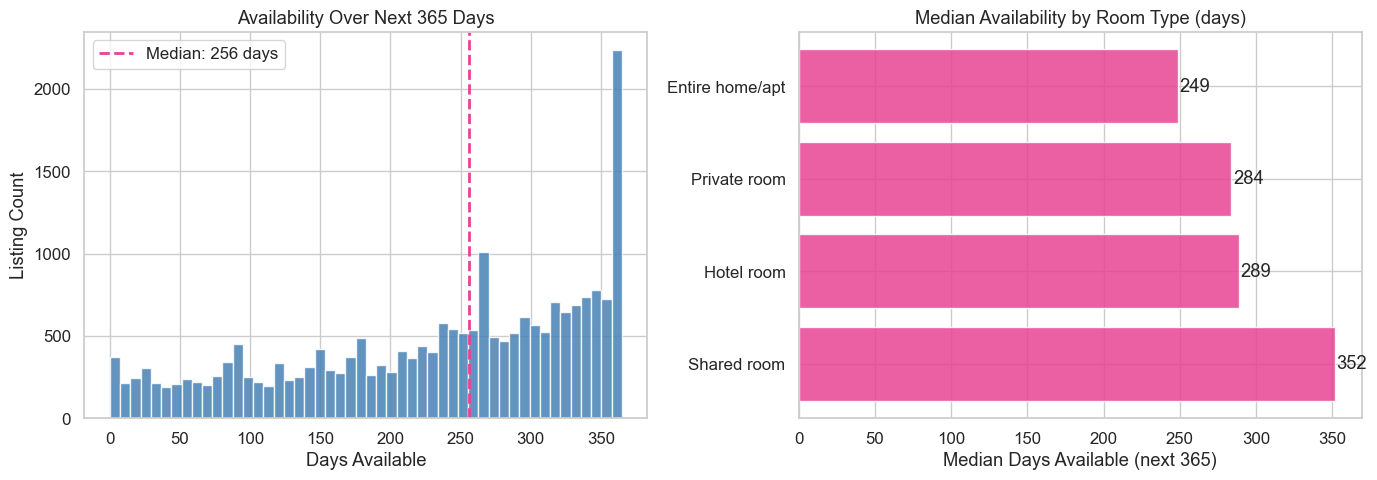

Listings with 0 availability (inactive / fully blocked): 178 (0.8%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# availability_365 histogram
avail = df['availability_365'].dropna()
axes[0].hist(avail, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(avail.median(), color=ACCENT, ls='--', lw=2,
                label=f'Median: {avail.median():.0f} days')
axes[0].set_title('Availability Over Next 365 Days')
axes[0].set_xlabel('Days Available')
axes[0].set_ylabel('Listing Count')
axes[0].legend()

# Availability by room type
room_avail = (
    df.groupby('room_type')['availability_365']
    .median().sort_values(ascending=False)
)
axes[1].barh(room_avail.index, room_avail.values, color=ACCENT, alpha=0.85)
axes[1].set_title('Median Availability by Room Type (days)')
axes[1].set_xlabel('Median Days Available (next 365)')
for i, v in enumerate(room_avail.values):
    axes[1].text(v + 1, i, str(int(v)), va='center')

plt.tight_layout()
plt.savefig('../../reports/figures/4_1_availability.png', dpi=150, bbox_inches='tight')
plt.show()

# Zero availability listings
zero_avail = (df['availability_365'] == 0).sum()
print(f"Listings with 0 availability (inactive / fully blocked): "
      f"{zero_avail} ({zero_avail/len(df)*100:.1f}%)")

> **Business Interpretation: Calendar Dynamics & Asset Utilization**
> 
> * **The Commercial "Always-On" Tier:** The histogram reveals a massive, towering spike at the extreme right edge (365 days). This absolute truth indicates that a highly significant portion of Cape Town's inventory operates as full-time, dedicated short-term rental businesses, entirely available year-round. This is not the casual "sharing economy"; this is commercial real estate.
> * **Rolling Calendar Management:** The histogram also shows distinct, smaller peaks at regular intervals before 365 days (e.g., around the 90, 180, and 270-day marks). This suggests professional hosts are utilizing rolling calendar windows—only allowing guests to book 3 or 6 months in advance to protect themselves from inflation or missing out on future peak-season surge pricing.
> * **Asset Class Utilization:** The bar chart (right) proves that different property types are utilized differently. "Shared rooms" operate almost identically to permanent hostels, with a median availability of 352 days. "Entire homes/apts," however, have the lowest median availability (249 days). This suggests the "Entire home" category contains a high mix of part-time hosts who live in the property for part of the year and only rent it out during specific windows (like the December holiday season).
> * **Active Market Health:** Only 0.8% (178 listings) have exactly zero availability. This means the cleaned dataset is exceptionally healthy and represents active, participating supply rather than dormant "ghost" listings.
> 
> **Strategic Takeaways:**
> 1. **For Revenue Management Systems:** Pricing recommendation engines must recognize rolling calendar blocks. If a host only opens their calendar 3 months in advance, the algorithm cannot use 6-month forward-looking data to suggest their prices.
> 2. **For City Regulators & Policy:** The massive spike at 365 days provides empirical evidence to city planners that a large volume of housing stock has been permanently converted into tourist accommodation, which is often a key metric used when drafting short-term rental legislation.